In [33]:
#installing Libraries
!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow

In [53]:
#IMPORTING LIBRARIES

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [55]:
#Load Stock Data

stock = "TCS.NS"    # WE CAN USE OTHER DATA ALSO LIKE (RELIANCE.NS, TCS.NS, INFY.NS)

data = yf.download(stock, period="2y")

data = data[['Close']]
data.dropna(inplace=True)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,TCS.NS
Date,
2024-04-01,3673.169922
2024-04-02,3642.269287
2024-04-03,3701.820312
2024-04-04,3754.337402
2024-04-05,3731.783203


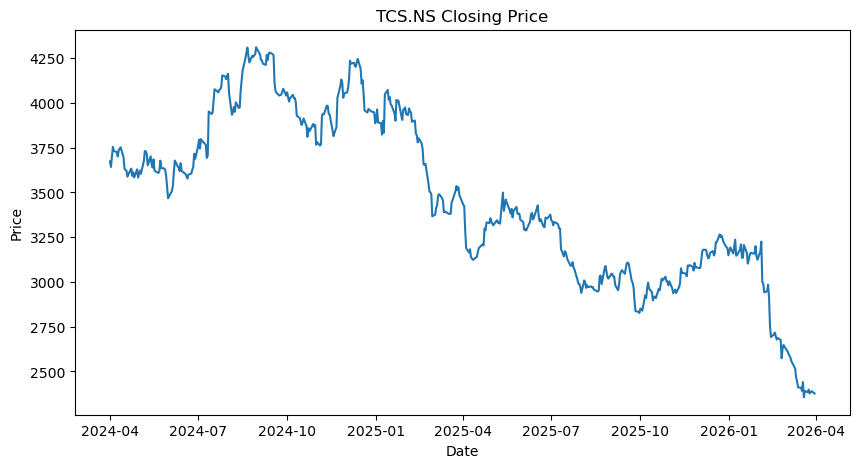

In [57]:
#VISUALIZE THE DATA

plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title(f"{stock} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [59]:
#DATA PRE-PROCESSING

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (435, 60, 1)
y shape: (435, 1)


In [61]:
# Build LSTM Model

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

C:\Users\msi\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
#TRAIN THE MODEL

model.fit(X, y, epochs=100, batch_size=32)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.2069
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0148
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0089
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0067
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0045
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0037
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0039
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0038
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0036
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0037
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0032
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0035
Epoch 13/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0041
Epoch 14/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0031
Epoch 15/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - lo

In [65]:
#Predict Next Day Price

last_60_days = scaled_data[-60:]

last_60_days = last_60_days.reshape(1, 60, 1)

prediction = model.predict(last_60_days)
prediction = scaler.inverse_transform(prediction)

print("📊 Next Day Predicted Price:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
📊 Next Day Predicted Price: 2364.8438


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 


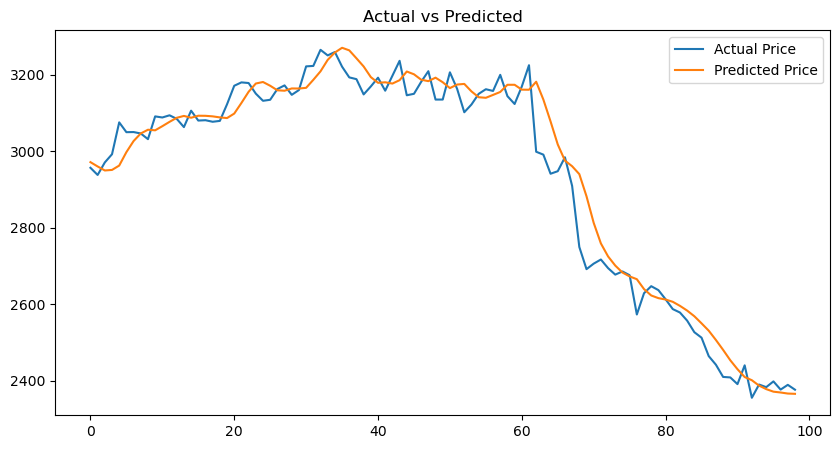

In [67]:
# Compare Actual vs Predicted

train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - 60:]

X_test, y_test = [], []

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i])
    y_test.append(test_data[i])

X_test, y_test = np.array(X_test), np.array(y_test)

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()